In [1]:
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns 
import numpy as np
import re
import random
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

clinical_df = pd.read_csv("../data/TCGA-BRCA.clinical.tsv", sep="\t")
gene_level_abs_df = pd.read_csv("../data/TCGA-BRCA.gene-level_absolute.tsv", sep="\t")
 
clinical_df.head()  



,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,days_to_collection.samples,initial_weight.samples,preservation_method.samples,pathology_report_uuid.samples,oct_embedded.samples,specimen_type.samples,days_to_sample_procurement.samples,is_ffpe.samples,tissue_type.samples,annotations.samples
0,TCGA-BH-A0W3-01A,3c612e12-6de8-44fa-a095-805c45474821,Ductal and Lobular Neoplasms,3c612e12-6de8-44fa-a095-805c45474821,TCGA-BH-A0W3,Breast,Not Reported,white,female,not hispanic or latino,...,85.0,120.0,OCT,801A4E2F-E26E-424F-BF42-CD0D9CD62BCE,True,Solid Tissue,NaN,False,Tumor,NaN
1,TCGA-AR-A24V-01A,3cb06c7a-f2a8-448b-91a8-dd201bbf2ddd,Ductal and Lobular Neoplasms,3cb06c7a-f2a8-448b-91a8-dd201bbf2ddd,TCGA-AR-A24V,Breast,Not Reported,white,female,not hispanic or latino,...,1720.0,400.0,OCT,468CD293-C9F7-43C6-A40A-18FCDD22F6AA,True,Solid Tissue,NaN,False,Tumor,NaN
2,TCGA-E9-A1NE-01A,3d676bba-154b-4d22-ab59-d4d4da051b94,Ductal and Lobular Neoplasms,3d676bba-154b-4d22-ab59-d4d4da051b94,TCGA-E9-A1NE,Breast,Not Reported,white,female,not hispanic or latino,...,31.0,280.0,OCT,CF6E29A2-FAE6-45BB-B625-33877887A89E,True,Solid Tissue,NaN,False,Tumor,NaN
3,TCGA-E9-A1NE-11A,3d676bba-154b-4d22-ab59-d4d4da051b94,Ductal and Lobular Neoplasms,3d676bba-154b-4d22-ab59-d4d4da051b94,TCGA-E9-A1NE,Breast,Not Reported,white,female,not hispanic or latino,...,31.0,830.0,OCT,NaN,True,Solid Tissue,NaN,False,Normal,NaN
4,TCGA-AC-A8OQ-01A,dfaabd03-2d40-4422-b210-caf112ff4229,Ductal and Lobular Neoplasms,dfaabd03-2d40-4422-b210-caf112ff4229,TCGA-AC-A8OQ,Breast,Not Reported,black or african american,female,not hispanic or latino,...,742.0,100.0,Unknown,FFA6F9F3-71C1-4AF9-B9F7-0466550EBC90,False,Solid Tissue,NaN,False,Tumor,NaN


In [2]:
%pip install pandas matplotlib seaborn numpy pydeseq2

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install pandas matplotlib seaborn numpy pydeseq2

In [4]:
#sorted(clinical_df["ajcc_pathologic_stage.diagnoses"].dropna().unique())

In [5]:
# Calculate the percentage of each stage
#stage_percentages = clinical_df['ajcc_pathologic_stage.diagnoses'].value_counts(normalize=True) * 100

# Sort the percentages in descending order
#sorted_stage_percentages = stage_percentages.sort_values(ascending=False)

# Print the sorted percentages
#print(sorted_stage_percentages)



# Data Wrangling 
### Clinical Data 

In [6]:
# Remove 'Stage ' before Roman numerals in 'ajcc_pathologic_stage.diagnoses' and drop NaN values

clinical_df['ajcc_pathologic_stage.diagnoses'] = clinical_df['ajcc_pathologic_stage.diagnoses'].str.replace(r'^Stage ', '', regex=True)

clinical_df = clinical_df.dropna(subset=['ajcc_pathologic_stage.diagnoses'])



# Capitalize the first letter of each entry in the 'gender.demographic' column
clinical_df['gender.demographic'] = clinical_df['gender.demographic'].str.capitalize()

# Drop NaN values and convert 'age_at_index.demographic' to integers
clinical_df = clinical_df.dropna(subset=['age_at_index.demographic'])
clinical_df['age_at_index.demographic'] = clinical_df['age_at_index.demographic'].astype(int)

# Clean 'race.demographic' by removing 'not reported' and replacing 'black or african american' with 'black'
clinical_df = clinical_df[clinical_df['race.demographic'] != 'not reported']
clinical_df['race.demographic'] = clinical_df['race.demographic'].replace('black or african american', 'black')

# View the updated dataframe
clinical_df[['ajcc_pathologic_stage.diagnoses', 'gender.demographic', 'age_at_index.demographic', 'race.demographic']].head()



,ajcc_pathologic_stage.diagnoses,gender.demographic,age_at_index.demographic,race.demographic
0,IIA,Female,58,white
1,IIB,Female,52,white
2,IIB,Female,28,white
3,IIB,Female,28,white
4,IIB,Female,72,black


In [7]:
# Filter rows ending in '01A' and '11A', select 99 random samples for each, and extract the 'sample' column as 'TCGA ID'
analysis_df = (clinical_df[clinical_df['sample'].str.endswith('01A')]
               .sample(n=99, random_state=34)
               [['sample']].rename(columns={'sample': 'TCGA ID'}))

additional_df = (clinical_df[clinical_df['sample'].str.endswith('11A')]
                 .sample(n=99, random_state=3)
                 [['sample']].rename(columns={'sample': 'TCGA ID'}))

# Append the additional rows to the analysis_df
analysis_df = pd.concat([analysis_df, additional_df], ignore_index=True)

# Merge demographic and tumor stage data from clinical_df
analysis_df = analysis_df.merge(clinical_df[['sample', 'race.demographic', 'gender.demographic', 
                                              'age_at_index.demographic', 'ajcc_pathologic_stage.diagnoses']],
                                 how='left', left_on='TCGA ID', right_on='sample')

# Drop the original 'sample' column after merging
analysis_df.drop(columns=['sample'], inplace=True)

# Create additional columns (Sample ID, Group, Cancer Type, Sample Type, Gender, Age, Race, Tumor Stage)
analysis_df['Sample ID'] = ['breast_cancer' + str(i+1) for i in range(99)] + ['breast_control' + str(i+1) for i in range(99)]
analysis_df['Group'] = ['Cancer'] * 99 + ['Control'] * 99
analysis_df['Cancer Type'] = ['Breast Invasive Carcinoma'] * 99 + ['Breast Control'] * 99
analysis_df['Sample Type'] = ['primary tumor'] * 99 + ['normal tissue'] * 99

# Create 'Gender', 'Age', 'Race', and 'Tumor Stage' columns
analysis_df['Gender'] = analysis_df['gender.demographic']
analysis_df['Age'] = analysis_df['age_at_index.demographic']
analysis_df['Race'] = analysis_df['race.demographic']
analysis_df['Tumor Stage'] = analysis_df['ajcc_pathologic_stage.diagnoses']

# Reorder columns
cols = ['Sample ID', 'TCGA ID', 'Group', 'Cancer Type', 'Gender', 'Age', 'Race', 'Sample Type', 'Tumor Stage']
analysis_df = analysis_df[cols]

analysis_df.head() 






,Sample ID,TCGA ID,Group,Cancer Type,Gender,Age,Race,Sample Type,Tumor Stage
0,breast_cancer1,TCGA-B6-A0RO-01A,Cancer,Breast Invasive Carcinoma,Female,71,white,primary tumor,IIIB
1,breast_cancer2,TCGA-AC-A23H-01A,Cancer,Breast Invasive Carcinoma,Female,90,white,primary tumor,IIA
2,breast_cancer3,TCGA-B6-A0X0-01A,Cancer,Breast Invasive Carcinoma,Female,54,white,primary tumor,I
3,breast_cancer4,TCGA-AR-A1AY-01A,Cancer,Breast Invasive Carcinoma,Female,65,white,primary tumor,I
4,breast_cancer5,TCGA-E2-A15O-01A,Cancer,Breast Invasive Carcinoma,Female,89,black,primary tumor,I


In [8]:
#clinical_df.info()

In [9]:
# Prints number of missing values in each column 

pd.set_option('display.max_columns', None) 

missing_values = clinical_df.isnull().sum()
print(missing_values)



sample                                   0
id                                       0
disease_type                             0
case_id                                  0
submitter_id                             0
                                      ... 
specimen_type.samples                    0
days_to_sample_procurement.samples    1144
is_ffpe.samples                          0
tissue_type.samples                      0
annotations.samples                   1147
Length: 85, dtype: int64


In [10]:
# Columns to remove from df 
columns_to_drop = [
    'entity_submitter_id.annotations', 
    'notes.annotations',
    'submitter_id.annotations',
    'classification.annotations',
    'entity_id.annotations',
    'created_datetime.annotations',
    'annotation_id.annotations',
    'entity_type.annotations',
    'updated_datetime.annotations',
    'case_id.annotations',
    'state.annotations',
    'category.annotations',
    'status.annotations',
    'case_submitter_id.annotations',
    'days_to_sample_procurement.samples',
    'annotations.samples'
]

clinical_df = clinical_df.drop(columns=columns_to_drop)

print(clinical_df.columns)




Index(['sample', 'id', 'disease_type', 'case_id', 'submitter_id',
       'primary_site', 'alcohol_history.exposures', 'race.demographic',
       'gender.demographic', 'ethnicity.demographic',
       'vital_status.demographic', 'age_at_index.demographic',
       'days_to_birth.demographic', 'year_of_birth.demographic',
       'year_of_death.demographic', 'primary_site.project',
       'project_id.project', 'disease_type.project', 'name.project',
       'name.program.project', 'tissue_source_site_id.tissue_source_site',
       'code.tissue_source_site', 'name.tissue_source_site',
       'project.tissue_source_site', 'bcr_id.tissue_source_site',
       'days_to_death.demographic', 'synchronous_malignancy.diagnoses',
       'ajcc_pathologic_stage.diagnoses', 'days_to_diagnosis.diagnoses',
       'last_known_disease_status.diagnoses',
       'tissue_or_organ_of_origin.diagnoses',
       'days_to_last_follow_up.diagnoses', 'age_at_diagnosis.diagnoses',
       'primary_diagnosis.diagnoses', '

In [11]:
clinical_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1148 entries, 0 to 1254
Data columns (total 69 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sample                                                     1148 non-null   object 
 1   id                                                         1148 non-null   object 
 2   disease_type                                               1148 non-null   object 
 3   case_id                                                    1148 non-null   object 
 4   submitter_id                                               1148 non-null   object 
 5   primary_site                                               1148 non-null   object 
 6   alcohol_history.exposures                                  1148 non-null   object 
 7   race.demographic                                           1148 non-null   object 
 8   gender.demogr

In [12]:
gene_level_abs_df.shape

(60623, 1058)

In [13]:
gene_level_ascat2_df = pd.read_csv("../data/TCGA-BRCA.gene-level_ascat2.tsv", sep="\t")


In [14]:
gene_level_ascat3_df = pd.read_csv("../data/TCGA-BRCA.gene-level_ascat3.tsv", sep="\t")



In [15]:
protein_df = pd.read_csv("../data/TCGA-BRCA.protein.tsv", sep="\t")

protein_df.head()




,peptide_target,TCGA-WT-AB41-01A,TCGA-BH-A0H5-01A,TCGA-C8-A27A-01A,TCGA-AC-A23C-01A,TCGA-A8-A085-01A,TCGA-D8-A27M-01A,TCGA-A2-A0T4-01A,TCGA-A2-A0YF-01A,TCGA-A2-A0YL-01A,TCGA-A2-A04T-01A,TCGA-PE-A5DD-01A,TCGA-E9-A1N5-01A,TCGA-A7-A26I-01A,TCGA-A2-A25A-01A,TCGA-AO-A0J6-01A,TCGA-A7-A4SC-11A,TCGA-BH-A0EB-01A,TCGA-C8-A27B-01A,TCGA-A2-A0CM-01A,TCGA-D8-A1X5-01A,TCGA-A2-A1FW-01A,TCGA-A8-A09B-01A,TCGA-BH-A209-01A,TCGA-BH-A0H9-01A,TCGA-E9-A1RI-01A,TCGA-AR-A2LJ-01A,TCGA-EW-A1P8-01A,TCGA-3C-AALK-01A,TCGA-D8-A27I-01A,TCGA-AO-A0J9-01A,TCGA-BH-A1F6-01A,TCGA-AO-A12H-01A,TCGA-BH-A0B2-01A,TCGA-LL-A740-01A,TCGA-E2-A15S-01A,TCGA-AN-A0XP-01A,TCGA-A8-A09C-01A,TCGA-EW-A1J5-01A,TCGA-E2-A1LB-01A,TCGA-A2-A1G4-01A,TCGA-B6-A0RH-01A,TCGA-A8-A06R-01A,TCGA-EW-A1IZ-01A,TCGA-AR-A0TX-01A,TCGA-A2-A0SU-01A,TCGA-BH-A0DK-11A,TCGA-BH-A0EE-01A,TCGA-AO-A129-01A,TCGA-A2-A0CX-01A,TCGA-D8-A1JH-01A,TCGA-GM-A2DL-01A,TCGA-AR-A1AT-01A,TCGA-E9-A3Q9-01A,TCGA-E9-A5FL-01A,TCGA-A7-A0DB-01A,TCGA-BH-A0BP-01A,TCGA-AO-A1KO-01A,TCGA-BH-A0DK-01A,TCGA-E9-A1RF-11A,TCGA-E2-A156-01A,TCGA-E9-A1ND-01A,TCGA-E9-A1ND-11A,TCGA-E2-A109-01A,TCGA-E2-A1L8-01A,TCGA-E9-A3QA-01A,TCGA-A2-A0YG-01A,TCGA-C8-A3M8-01A,TCGA-D8-A27P-01A,TCGA-AC-A2QI-01A,TCGA-E9-A1NI-01A,TCGA-E9-A1R0-01A,TCGA-E9-A1RF-01A,TCGA-B6-A0RQ-01A,TCGA-AR-A0TZ-01A,TCGA-A2-A25F-01A,TCGA-E2-A15D-01A,TCGA-OL-A5D7-01A,TCGA-A2-A4RX-01A,TCGA-AR-A0TR-01A,TCGA-AQ-A1H2-01A,TCGA-E2-A152-01A,TCGA-EW-A1PD-01A,TCGA-AN-A0XN-01A,TCGA-AO-A03P-01A,TCGA-AN-A0AR-01A,TCGA-AR-A1AM-01A,TCGA-BH-A203-01A,TCGA-BH-A1FJ-01A,TCGA-BH-A203-11A,TCGA-C8-A26V-01A,TCGA-A8-A08X-01A,TCGA-LL-A5YN-01A,TCGA-A7-A4SC-01A,TCGA-C8-A1HO-01A,TCGA-D8-A146-01A,TCGA-A8-A09K-01A,TCGA-A8-A07I-01A,TCGA-AO-A1KQ-01A,TCGA-OL-A6VQ-01A,TCGA-D8-A27R-01A,TCGA-E2-A1LE-01A,TCGA-AR-A24T-01A,TCGA-AR-A252-01A,TCGA-BH-A0DI-01A,TCGA-AC-A2FG-01A,TCGA-A2-A0CR-01A,TCGA-BH-A0W5-01A,TCGA-D8-A1JG-01B,TCGA-GM-A2DF-01A,TCGA-BH-A0BM-01A,TCGA-BH-A0BZ-01A,TCGA-BH-A0BW-01A,TCGA-BH-A1FE-06A,TCGA-A8-A07F-01A,TCGA-AO-A128-01A,TCGA-E2-A15T-01A,TCGA-E2-A14V-01A,TCGA-A1-A0SH-01A,TCGA-A7-A6VV-01A,TCGA-A2-A3XT-01A,TCGA-BH-A0HL-01A,TCGA-UL-AAZ6-01A,TCGA-AC-A23E-01A,TCGA-A2-A0EQ-01A,TCGA-BH-A1F8-11B,TCGA-AR-A0U2-01A,TCGA-E2-A574-01A,TCGA-BH-A0DP-11A,TCGA-BH-A18T-01A,TCGA-E2-A14S-01A,TCGA-BH-A0BQ-01A,TCGA-C8-A131-01A,TCGA-BH-A0B4-01A,TCGA-EW-A424-01A,TCGA-GM-A2DK-01A,TCGA-A2-A0CV-01A,TCGA-AC-A62X-01A,TCGA-EW-A6S9-01A,TCGA-D8-A1X6-01A,TCGA-AO-A03M-01B,TCGA-A8-A06N-01A,TCGA-EW-A1IX-01A,TCGA-E2-A1L6-01A,TCGA-A2-A04Q-01A,TCGA-E2-A15I-01A,TCGA-GM-A3XG-01A,TCGA-A2-A0YT-01A,TCGA-Z7-A8R5-01A,TCGA-BH-A0BV-01A,TCGA-A2-A0YI-01A,TCGA-A2-A0ER-01A,TCGA-E9-A24A-01A,TCGA-D8-A1XO-01A,TCGA-BH-A1F2-01A,TCGA-BH-A18N-11A,TCGA-B6-A0RU-01A,TCGA-LL-A441-01A,TCGA-D8-A1JE-01A,TCGA-BH-A0E6-01A,TCGA-B6-A0IQ-01A,TCGA-AR-A24O-01A,TCGA-AO-A0JC-01A,TCGA-GM-A3XL-01A,TCGA-B6-A0IO-01A,TCGA-A2-A04W-01A,TCGA-E9-A1N3-01A,TCGA-E9-A54X-01A,TCGA-BH-A0C0-01A,TCGA-AO-A0J5-01A,TCGA-E2-A1L7-01A,TCGA-AN-A0XW-01A,TCGA-E9-A1R4-01A,TCGA-A2-A0D4-01A,TCGA-AR-A24Q-01A,TCGA-AO-A03N-01B,TCGA-D8-A1XV-01A,TCGA-BH-A18L-01A,TCGA-D8-A1XR-01A,TCGA-E9-A22G-01A,TCGA-A2-A0EP-01A,TCGA-AR-A0TS-01A,TCGA-BH-A0B0-01A,TCGA-AO-A124-01A,TCGA-B6-A0RM-01A,TCGA-E2-A15L-01A,TCGA-AC-A2FF-01A,TCGA-BH-A1FE-01A,TCGA-AC-A4ZE-01A,TCGA-AN-A0FZ-01A,TCGA-A8-A095-01A,TCGA-C8-A12V-01A,TCGA-EW-A1PC-01B,TCGA-D8-A27G-01A,TCGA-A7-A26F-01A,TCGA-E2-A1B1-01A,TCGA-EW-A1J2-01A,TCGA-A8-A08P-01A,TCGA-C8-A1HN-01A,TCGA-AR-A0U3-01A,TCGA-E2-A108-01A,TCGA-GM-A5PV-01A,TCGA-AC-A3W7-01A,TCGA-BH-A6R8-01A,TCGA-BH-A0HN-01A,TCGA-AR-A24K-01A,TCGA-BH-A0DP-01A,TCGA-A1-A0SK-01A,TCGA-B6-A0RO-01A,TCGA-A2-A0T2-01A,TCGA-A7-A4SF-01A,TCGA-A8-A07R-01A,TCGA-BH-A18G-01A,TCGA-BH-A1F5-01A,TCGA-AR-A0U4-01A,TCGA-BH-A0DT-01A,TCGA-E2-A14N-01A,TCGA-A7-A3RF-01A,TCGA-AR-A5QM-01A,TCGA-A2-A4S2-01A,TCGA-A2-A04Y-01A,TCGA-E2-A10C-01A,TCGA-AR-A24W-01A,TCGA-A7-A0CE-01A,TCGA-C8-A12W-01A,TCGA-GM-A2DI-01A,TCGA-AO-A03L-01A,TCGA-HN-A2NL-01A,TCGA-D8-A1JC-01A,TCGA-A8-A07W-01A,TCGA-B6-A0I6-01A,TCGA-AC-A5EI-01A,TCGA-OL-A5RW-01A,TCGA-BH-A1EY-01A,TCGA-AN-A0AL-01A,TCGA-B

In [16]:
somatic_mutation_df = pd.read_csv("../data/TCGA-BRCA.somaticmutation_wxs.tsv", sep="\t")

somatic_mutation_df.head()


,sample,gene,chrom,start,end,ref,alt,Tumor_Sample_Barcode,Amino_Acid_Change,effect,callers,dna_vaf
0,TCGA-A1-A0SO-01A,MIB2,chr1,1625276,1625299,CCCTCCGCAGGCAAGCCGGCGGAG,-,TCGA-A1-A0SO-01A-22D-A099-09,p.X356_splice,splice_acceptor_variant;coding_sequence_varian...,mutect2;varscan2,0.300000
1,TCGA-A1-A0SO-01A,VPS13D,chr1,12283654,12283654,T,C,TCGA-A1-A0SO-01A-22D-A099-09,p.I1851T,missense_variant,muse;mutect2;varscan2,0.179775
2,TCGA-A1-A0SO-01A,PRAMEF8,chr1,13281907,13281907,C,A,TCGA-A1-A0SO-01A-22D-A099-09,p.V297F,missense_variant,muse;mutect2,0.031496
3,TCGA-A1-A0SO-01A,NBPF1,chr1,16576355,16576355,C,G,TCGA-A1-A0SO-01A-22D-A099-09,p.E677D,missense_variant,muse;mutect2,0.086957
4,TCGA-A1-A0SO-01A,SRSF4,chr1,29148880,29148880,C,T,TCGA-A1-A0SO-01A-22D-A099-09,p.G339S,missense_variant,muse;mutect2;varscan2,0.134615


# Data Wrangling 
## Creating Metadata and Counts Data Sets 

In [17]:
# Load RNA-seq counts
rna_seq_df = pd.read_csv("../data/TCGA-BRCA.star_counts.tsv", sep="\t")

# Rename and format RNA-seq data
rna_seq_df.rename(columns={"Ensembl_ID": "Gene ID"}, inplace=True)
rna_seq_df.set_index("Gene ID", inplace=True)
rna_seq_df = rna_seq_df.T.reset_index().rename(columns={"index": "TCGA ID"})

# Merge with metadata
seq_analysis_df = pd.merge(analysis_df, rna_seq_df, how='left', on='TCGA ID').set_index("TCGA ID")

# Define metadata columns
metadata_columns = ["Sample ID", "Group", "Cancer Type", "Gender", "Age", "Race", "Sample Type", "Tumor Stage"]

# Separate metadata and counts
metadata_df = seq_analysis_df[metadata_columns]
counts_df = seq_analysis_df.drop(columns=metadata_columns).T  # Transpose for PyDESeq2

# Step 1: Drop columns in the '11A' group that contain only NaN values
control_nan_columns = [col for col in counts_df.columns if col.endswith('11A') and counts_df[col].isna().all()]
counts_df = counts_df.drop(columns=control_nan_columns)

# Step 2: Count how many '11A' columns were dropped
dropped_columns_count = len(control_nan_columns)

# Step 3: Randomly drop the same number of columns from the '01A' group
if dropped_columns_count > 0:
    cancer_columns = [col for col in counts_df.columns if col.endswith('01A')]
    
    # Make sure there are enough '01A' columns to drop
    if len(cancer_columns) >= dropped_columns_count:
        columns_to_drop = random.sample(cancer_columns, dropped_columns_count)
        counts_df = counts_df.drop(columns=columns_to_drop)

# Optionally, print how many columns were dropped
print(f"Dropped {dropped_columns_count} '11A' columns and {len(columns_to_drop)} '01A' columns.")

# Step 4: Drop the corresponding rows in the metadata_df
dropped_tcgais = [col.split('_')[0] for col in control_nan_columns + columns_to_drop]  # Extract TCGA IDs from the column names
metadata_df = metadata_df[~metadata_df.index.isin(dropped_tcgais)]  # Drop rows based on TCGA ID

metadata_df.shape


Dropped 17 '11A' columns and 17 '01A' columns.


(164, 8)

In [18]:
metadata_df.head(164)

,Sample ID,Group,Cancer Type,Gender,Age,Race,Sample Type,Tumor Stage
TCGA ID,,,,,,,,
TCGA-AC-A23H-01A,breast_cancer2,Cancer,Breast Invasive Carcinoma,Female,90,white,primary tumor,IIA
TCGA-B6-A0X0-01A,breast_cancer3,Cancer,Breast Invasive Carcinoma,Female,54,white,primary tumor,I
TCGA-AR-A1AY-01A,breast_cancer4,Cancer,Breast Invasive Carcinoma,Female,65,white,primary tumor,I
TCGA-E2-A572-01A,breast_cancer7,Cancer,Breast Invasive Carcinoma,Female,72,black,primary tumor,IIIA
TCGA-A2-A0CW-01A,breast_cancer8,Cancer,Breast Invasive Carcinoma,Female,67,white,primary tumor,IIB
...,...,...,...,...,...,...,...,...
TCGA-BH-A0HK-11A,breast_control94,Control,Breast Control,Female,81,white,normal tissue,IIB
TCGA-BH-A203-11A,breast_control96,Control,Breast Control,Female,78,white,normal tissue,IIB
TCGA-BH-A0C0-11A,breast_control97,Control,Breast Control,Female,62,white,normal tissue,IIA


In [19]:
counts_df.head()

TCGA ID,TCGA-AC-A23H-01A,TCGA-B6-A0X0-01A,TCGA-AR-A1AY-01A,TCGA-E2-A572-01A,TCGA-A2-A0CW-01A,TCGA-D8-A13Y-01A,TCGA-AN-A0XW-01A,TCGA-A1-A0SQ-01A,TCGA-GM-A2DL-01A,TCGA-AO-A0JL-01A,TCGA-AO-A0J2-01A,TCGA-OL-A5RY-01A,TCGA-AO-A03R-01A,TCGA-D8-A1JI-01A,TCGA-EW-A2FW-01A,TCGA-OL-A5DA-01A,TCGA-B6-A0IG-01A,TCGA-A2-A25B-01A,TCGA-W8-A86G-01A,TCGA-C8-A134-01A,TCGA-AN-A0AM-01A,TCGA-A7-A13E-01A,TCGA-S3-AA11-01A,TCGA-S3-AA14-01A,TCGA-AO-A0JF-01A,TCGA-E2-A106-01A,TCGA-E2-A1IE-01A,TCGA-BH-A0GY-01A,TCGA-E9-A1RH-01A,TCGA-Z7-A8R5-01A,TCGA-OL-A5RX-01A,TCGA-LL-A6FP-01A,TCGA-AN-A0XV-01A,TCGA-EW-A2FV-01A,TCGA-AN-A0AS-01A,TCGA-LL-A5YM-01A,TCGA-C8-A26X-01A,TCGA-C8-A275-01A,TCGA-E9-A1R6-01A,TCGA-E2-A1B1-01A,TCGA-E2-A1B5-01A,TCGA-EW-A6SB-01A,TCGA-A2-A04N-01A,TCGA-A2-A0EW-01A,TCGA-C8-A1HJ-01A,TCGA-BH-A18S-01A,TCGA-E2-A1IN-01A,TCGA-AR-A1AK-01A,TCGA-AR-A250-01A,TCGA-D8-A1XV-01A,TCGA-BH-A42V-01A,TCGA-E9-A22B-01A,TCGA-BH-A1FJ-01A,TCGA-BH-A0E1-01A,TCGA-D8-A1XJ-01A,TCGA-D8-A73W-01A,TCGA-BH-A8G0-01A,TCGA-E2-A107-01A,TCGA-AQ-A54O-01A,TCGA-BH-A0HL-01A,TCGA-E2-A1B6-01A,TCGA-BH-A18Q-01A,TCGA-E9-A1N6-01A,TCGA-D8-A1XQ-01A,TCGA-D8-A1X7-01A,TCGA-AC-A62V-01A,TCGA-AC-A2QJ-01A,TCGA-A2-A0ST-01A,TCGA-LD-A7W6-01A,TCGA-E9-A54Y-01A,TCGA-C8-A130-01A,TCGA-BH-A1F2-01A,TCGA-AQ-A0Y5-01A,TCGA-AR-A1AN-01A,TCGA-EW-A1OX-01A,TCGA-B6-A0IK-01A,TCGA-AQ-A54N-01A,TCGA-A7-A13D-01A,TCGA-EW-A6S9-01A,TCGA-E2-A109-01A,TCGA-BH-A0DI-01A,TCGA-A7-A56D-01A,TCGA-A7-A0D9-11A,TCGA-E9-A1RI-11A,TCGA-A7-A13F-11A,TCGA-AC-A23H-11A,TCGA-BH-A0DG-11A,TCGA-BH-A0H7-11A,TCGA-BH-A1FU-11A,TCGA-BH-A18K-11A,TCGA-BH-A1F2-11A,TCGA-BH-A18R-11A,TCGA-E2-A1LS-11A,TCGA-E9-A1RF-11A,TCGA-BH-A0BC-11A,TCGA-BH-A0B5-11A,TCGA-BH-A0BT-11A,TCGA-BH-A209-11A,TCGA-BH-A0DK-11A,TCGA-BH-A0DD-11A,TCGA-BH-A1FC-11A,TCGA-BH-A204-11A,TCGA-BH-A1EN-11A,TCGA-AC-A2FF-11A,TCGA-E2-A153-11A,TCGA-A7-A0DB-11A,TCGA-BH-A0DZ-11A,TCGA-BH-A1EU-11A,TCGA-BH-A18M-11A,TCGA-E9-A1R7-11A,TCGA-E2-A158-11A,TCGA-BH-A0HA-11A,TCGA-BH-A18L-11A,TCGA-A7-A13E-11A,TCGA-BH-A18N-11A,TCGA-BH-A0BA-11A,TCGA-BH-A18Q-11A,TCGA-GI-A2C8-11A,TCGA-BH-A208-11A,TCGA-E2-A1L7-11A,TCGA-BH-A0BQ-11A,TCGA-BH-A0DL-11A,TCGA-BH-A0H9-11A,TCGA-BH-A18U-11A,TCGA-E9-A1RH-11A,TCGA-A7-A0CE-11A,TCGA-BH-A0H5-11A,TCGA-E9-A1NG-11A,TCGA-BH-A1FN-11A,TCGA-E9-A1N4-11A,TCGA-BH-A18V-11A,TCGA-E9-A1NF-11A,TCGA-E9-A1RC-11A,TCGA-E9-A1N5-11A,TCGA-E9-A1N9-11A,TCGA-BH-A0BM-11A,TCGA-BH-A0B8-11A,TCGA-BH-A1FB-11A,TCGA-BH-A0AU-11A,TCGA-E2-A1IG-11A,TCGA-GI-A2C9-11A,TCGA-BH-A0DV-11A,TCGA-BH-A0BZ-11A,TCGA-E9-A1N6-11A,TCGA-BH-A0DO-11A,TCGA-A7-A0DC-11A,TCGA-E9-A1RB-11A,TCGA-AC-A2FB-11A,TCGA-BH-A0E1-11A,TCGA-BH-A18S-11A,TCGA-BH-A0C3-11A,TCGA-BH-A0AZ-11A,TCGA-A7-A0CH-11A,TCGA-BH-A0AY-11A,TCGA-BH-A18P-11A,TCGA-BH-A18J-11A,TCGA-E9-A1RD-11A,TCGA-BH-A0DT-11A,TCGA-BH-A1EV-11A,TCGA-BH-A0HK-11A,TCGA-BH-A203-11A,TCGA-BH-A0C0-11A,TCGA-E2-A15I-11A,TCGA-BH-A0DP-11A
ENSG00000000003.15,9.252665,11.211888,11.687813,11.160502,9.529431,10.597121,10.405141,9.612868,10.302639,12.371504,11.600378,11.130571,10.101976,7.348728,10.901621,12.649032,11.832494,10.554589,12.262976,11.883407,11.288866,10.933322,8.888743,10.992230,10.969387,10.272630,11.715533,11.753217,8.344296,11.320801,12.052908,10.983706,12.803526,10.977995,11.283667,9.695228,10.219169,11.479275,10.068778,12.122504,10.057992,11.220378,11.755305,11.536247,12.619303,12.412570,12.528942,10.580259,11.047806,9.419960,11.579787,13.095562,11.475733,9.977280,11.817783,10.583083,11.228819,11.605942,11.367961,8.189825,11.518653,11.814182,9.257388,10.148477,10.928518,9.614710,10.264443,11.708222,11.849014,10.332037,11.994353,11.032735,9.781360,10.343186,9.824959,8.836050,11.154818,11.249706,10.209453,11.942881,11.165535,9.129283,11.816984,12.889504,11.673309,12.838613,13.191213,11.888743,11.278449,11.476746,12.601307,12.934981,11.963980,12.144658,11.960726,11.906515,12.321364,12.512987,12.337622,11.689998,11.575539,12.072133,12.285113,12.184565,11.446566,11.233620,11.936638,11.466586,11.794010,11.902375,10.827343,12.289443,11.828533,11.724514,12.200592,11.978710,12.897845,8.717676,12.630950,12.039605,12

In [20]:
# Step 1: Get TCGA IDs from counts_df columns and metadata_df index
counts_tcga_ids = counts_df.columns
metadata_tcga_ids = metadata_df.index

# Step 2: Check if they match
if set(counts_tcga_ids) == set(metadata_tcga_ids):
    print("The TCGA IDs align in both dataframes.")
else:
    print("The TCGA IDs do not align in both dataframes.")

The TCGA IDs align in both dataframes.


# Differential Gene Expression 
## QC on Counts Data 

In [21]:
# Load in counts/metadata of prepared CSV files 
counts = pd.read_csv("../data/processed_counts.csv", index_col=0)

In [22]:
# Read the CSV without setting "TCGA ID" as the index
metadata = pd.read_csv("../data/processed_metadata.csv")

# Now, "TCGA ID" will be a regular column, and you can manually set it as the index if needed
metadata.set_index("TCGA ID", inplace=True)


In [23]:
metadata.shape


(164, 8)

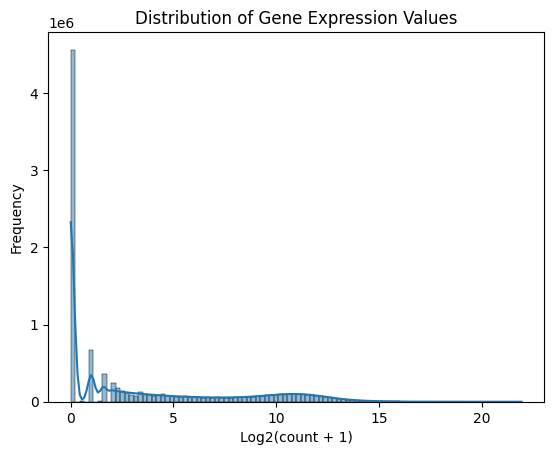

In [24]:
# Drop non-numeric columns (assuming first two columns are 'Gene' and 'Gene ID')
numeric_values = counts.iloc[:, 1:].to_numpy().flatten()

# Plot histogram
sns.histplot(numeric_values, bins=100, kde=True)
plt.xlabel("Log2(count + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")
plt.show()



# Filtering Counts Data


In [25]:
# Remove genes with values not greater than 0 
counts = counts.loc[(counts.iloc[:, 1:] > 0).sum(axis=1) > 0]
counts.shape

(56176, 165)

In [26]:
# Define threshold: remove genes expressed in fewer than 10% of samples
min_samples = int(0.1 * (counts.shape[1] - 2))  # Exclude first two columns (Gene ID, Gene Name)

# Apply filter only to numerical columns, skips 'Gene' column 
filtered_counts = counts.loc[
    (counts.iloc[:, 1:] > 1).sum(axis=1) >= min_samples
]

print(f"Original dataset: {counts.shape}")
print(f"Filtered dataset: {filtered_counts.shape}")



Original dataset: (56176, 165)
Filtered dataset: (37856, 165)


In [27]:
metadata.shape

(164, 8)

# PCA Analysis

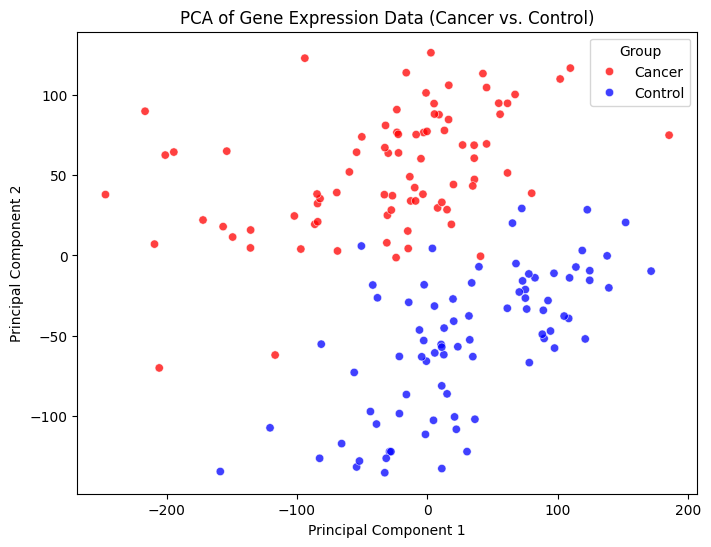

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Ensure the metadata index matches the sample IDs in counts
metadata = metadata.loc[filtered_counts.columns[1:], :]  # Remove gene columns

# Standardize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(filtered_counts.iloc[:, 1:].T)  # Exclude gene name columns

# Run PCA
pca = PCA(n_components=3)  # Increase to 3 components for 3D plot
pca_result = pca.fit_transform(scaled_data)

# Convert PCA results to DataFrame
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2", "PC3"])
pca_df.index = filtered_counts.columns[1:]  # Ensure correct sample IDs
pca_df["Group"] = metadata["Group"].values  # Assign group labels

# Plot PCA with groups (PC1 vs. PC2)
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="Group", data=pca_df, palette={"Cancer": "red", "Control": "blue"}, alpha=0.75)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Gene Expression Data (Cancer vs. Control)")
plt.legend(title="Group")

# Save the plot as a PNG before displaying it
plt.savefig("PCA_2D_Cancer_vs_Control.png", format="png", dpi=300)

# Display the plot
plt.show()




# PCA Loadings

In [29]:
print("Shape of PCA components:", pca.components_.shape)

# Check the number of columns (genes) in filtered_counts_df
print(filtered_counts.shape)  # Should match (n_samples, n_genes + 1)



Shape of PCA components: (3, 37856)
(37856, 165)


In [30]:
# Ensure the correct index is used for the genes
loadings_df = pd.DataFrame(pca.components_.T, index=filtered_counts.index, columns=["PC1", "PC2", "PC3"])

# Check the shape of the loadings DataFrame
print(loadings_df.shape)  # Should match (n_genes, 3)



(37856, 3)


In [31]:
# Sort the loadings for each principal component based on absolute values
loadings_sorted_pc1 = loadings_df["PC1"].abs().sort_values(ascending=False)
loadings_sorted_pc2 = loadings_df["PC2"].abs().sort_values(ascending=False)
loadings_sorted_pc3 = loadings_df["PC3"].abs().sort_values(ascending=False)


In [32]:
# Reset the index and check the columns
loadings_sorted_pc1_with_names = loadings_sorted_pc1.reset_index()

# Display the columns to find the correct name for the previous index column
print(loadings_sorted_pc1_with_names.columns)

# Add Gene Names to the loadings_sorted_pc1 DataFrame by mapping the Gene IDs (now in a column)
loadings_sorted_pc1_with_names['Gene Name'] = loadings_sorted_pc1_with_names[loadings_sorted_pc1_with_names.columns[0]].map(gene_id_to_name)

# Display the top 10 genes with names
print(loadings_sorted_pc1_with_names.head(10))

# Sort loadings for PC2 and PC3 by absolute values
loadings_sorted_pc2 = pd.Series(pca.components_[1], index=filtered_counts.index)
loadings_sorted_pc3 = pd.Series(pca.components_[2], index=filtered_counts.index)

# Map Gene IDs to Gene Names for PC2 and PC3
loadings_sorted_pc2_with_names = loadings_sorted_pc2.reset_index()
loadings_sorted_pc3_with_names = loadings_sorted_pc3.reset_index()

# Add Gene Names for PC2 and PC3
loadings_sorted_pc2_with_names['Gene Name'] = loadings_sorted_pc2_with_names[loadings_sorted_pc2_with_names.columns[0]].map(gene_id_to_name)
loadings_sorted_pc3_with_names['Gene Name'] = loadings_sorted_pc3_with_names[loadings_sorted_pc3_with_names.columns[0]].map(gene_id_to_name)

# Display the top 10 genes for PC2 and PC3
print("Top 10 genes driving PC2:")
print(loadings_sorted_pc2_with_names.head(10))

print("Top 10 genes driving PC3:")
print(loadings_sorted_pc3_with_names.head(10))




Index(['Gene ID', 'PC1'], dtype='object')


NameError: name 'gene_id_to_name' is not defined

Explained variance ratio for each component:
[0.16815632 0.11804324 0.05330749]


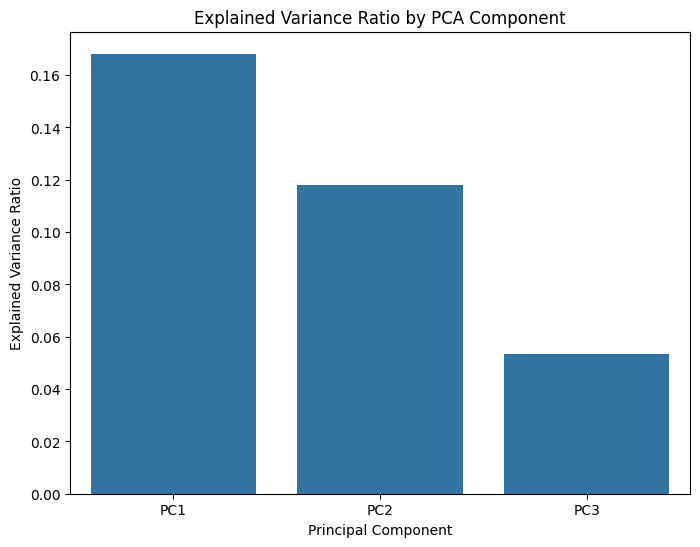

In [65]:
# Check explained variance ratio for each component
print("Explained variance ratio for each component:")
print(pca.explained_variance_ratio_)

# Plot explained variance ratio
plt.figure(figsize=(8, 6))
sns.barplot(x=["PC1", "PC2", "PC3"], y=pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio by PCA Component")
plt.show()


# Functional Analysis 

In [67]:
%pip install mygene
import mygene

# Initialize the MyGeneInfo object
mg = mygene.MyGeneInfo()

# Remove version numbers from Ensembl IDs
top_genes_pc1_cleaned = [gene.split('.')[0] for gene in top_genes_pc1]

# Query gene symbols for cleaned Ensembl Gene IDs
gene_info = mg.querymany(top_genes_pc1_cleaned, scopes='ensembl.gene', fields='symbol', species='human')

# Extract gene symbols from the query result
top_genes_pc1_symbols = [result['symbol'] for result in gene_info if 'symbol' in result]

# Print the gene symbols
print(top_genes_pc1_symbols)



Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 46 kB 427 kB/s eta 0:00:01
     |████████████████████████████████| 73 kB 3.3 MB/s eta 0:00:01
     |████████████████████████████████| 153 kB 9.9 MB/s eta 0:00:01
     |████████████████████████████████| 113 kB 7.4 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 7.5 MB/s eta 0:00:011
     |████████████████████████████████| 71 kB 9.9 MB/s  eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


NameError: name 'top_genes_pc1' is not defined

In [68]:
# Run the enrichment analysis with gene symbols
enrichment_results = gp.enrichr(
    gene_list=top_genes_pc1_symbols,
    gene_sets='GO_Biological_Process_2018',  # Or other gene sets like KEGG, Reactome, etc.
    organism='Human'
)

# Show the top enrichment results
print(enrichment_results.results.head(10))



NameError: name 'gp' is not defined

In [69]:
# Convert ENSG gene IDs to gene symbols using the gene_id_to_name dictionary
top_genes_pc1_symbols = [gene_id_to_name.get(gene_id, gene_id) for gene_id in top_genes_pc1]

# Run the KEGG enrichment analysis again with gene symbols
enrichment_results_kegg = gp.enrichr(
    gene_list=top_genes_pc1_symbols,  # Use gene symbols instead of ENSG IDs
    gene_sets='KEGG_2016',
    organism='Human'
)

# Display the top enriched KEGG pathways
print(enrichment_results_kegg.results.head(10))



NameError: name 'top_genes_pc1' is not defined

# Identify Outliers

In [70]:
from scipy.stats import zscore

# Compute Z-scores for each sample, ignoring the 'Gene' column
z_scores = counts.iloc[:, 1:].apply(zscore, axis=1)

# Identify samples with extreme values
outlier_samples = (z_scores.abs() > 3).sum(axis=0)

# Print samples that have at least one outlier
print(outlier_samples[outlier_samples > 0])




TCGA-AC-A23H-01A    742
TCGA-B6-A0X0-01A    343
TCGA-AR-A1AY-01A    678
TCGA-E2-A15O-01A    574
TCGA-EW-A6SC-01A    373
                   ... 
TCGA-BH-A0HK-11A    405
TCGA-BH-A203-11A    885
TCGA-BH-A0C0-11A    555
TCGA-E2-A15I-11A    293
TCGA-BH-A0DP-11A    437
Length: 164, dtype: int64


In [ ]:
# Sample Correlations 

# Compute correlation matrix
corr_matrix = np.corrcoef(filtered_counts.iloc[:, 1:].T)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", xticklabels=False, yticklabels=False)
plt.title("Sample Correlation Heatmap")
plt.show()


# Expression Analysis 

In [68]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Ensure "Gene" is set as index if not already
if filtered_counts.columns[0] == "Gene":
    filtered_counts = filtered_counts.set_index("Gene")

# Extract sample names
cancer_samples = metadata[metadata["Group"] == "Cancer"].index.tolist()
control_samples = metadata[metadata["Group"] == "Control"].index.tolist()

# Ensure filtered_counts contains only numeric data
filtered_counts_numeric = filtered_counts.loc[:, cancer_samples + control_samples].apply(pd.to_numeric, errors="coerce")

results = []
for gene in filtered_counts_numeric.index:
    try:
        # Extract cancer and control expression values
        cancer_expr = filtered_counts_numeric.loc[gene, cancer_samples].values.flatten()
        control_expr = filtered_counts_numeric.loc[gene, control_samples].values.flatten()

        # Perform Wilcoxon Rank-Sum Test
        stat, p_val = mannwhitneyu(cancer_expr, control_expr, alternative='two-sided')

        # Compute log2 Fold Change
        log2FC = np.mean(cancer_expr) - np.mean(control_expr)

        results.append((gene, p_val, log2FC))
    
    except Exception as e:
        print(f"Error processing gene {gene}: {e}")

# Convert to DataFrame
dge_results = pd.DataFrame(results, columns=["Gene", "p_value", "log2FC"])

# Adjust p-values (FDR correction)
dge_results["adj_p_value"] = multipletests(dge_results["p_value"], method="fdr_bh")[1]

# Sort and filter significant genes (FDR < 0.05, |log2FC| > 1)
significant_genes = dge_results[(dge_results["adj_p_value"] < 0.05) & (abs(dge_results["log2FC"]) > 1)]

# Sort the significant genes by log2FC in descending and ascending order
top_upregulated = significant_genes.sort_values(by="log2FC", ascending=False).head(15)
top_downregulated = significant_genes.sort_values(by="log2FC", ascending=True).head(15)

# Display the results
print("Top 15 Upregulated Genes:")
print(top_upregulated)

print("\nTop 15 Downregulated Genes:")
print(top_downregulated)


#significant_genes.head()




Top 15 Upregulated Genes:
            Gene       p_value    log2FC   adj_p_value
13124    COL10A1  1.790409e-25  6.552034  6.524213e-23
21453      MMP13  3.654111e-23  6.297698  3.309331e-21
34466       CST1  3.636087e-22  5.987306  2.376320e-20
35893      MMP11  6.640949e-28  5.633712  5.027996e-24
5870   LINC01614  2.242832e-24  5.268850  3.723887e-22
21450       MMP1  6.750268e-20  5.197253  2.026472e-18
9111        IBSP  4.554616e-27  5.188265  1.014233e-23
1661     COL11A1  1.706478e-22  5.095705  1.244709e-20
8476       S100P  4.260263e-18  4.825934  9.236914e-17
19754      PLPP4  5.574982e-23  4.790693  4.679524e-21
17138    SLC24A2  7.001205e-22  4.474815  4.180404e-20
3161        NEK2  3.313854e-26  4.414762  2.412486e-23
32767       COMP  1.498395e-22  4.401722  1.106369e-20
34819      UBE2C  8.831031e-26  4.327208  4.341656e-23
33966      TNNT1  1.661976e-15  4.253800  2.329351e-14

Top 15 Downregulated Genes:
            Gene       p_value    log2FC   adj_p_value
15057     

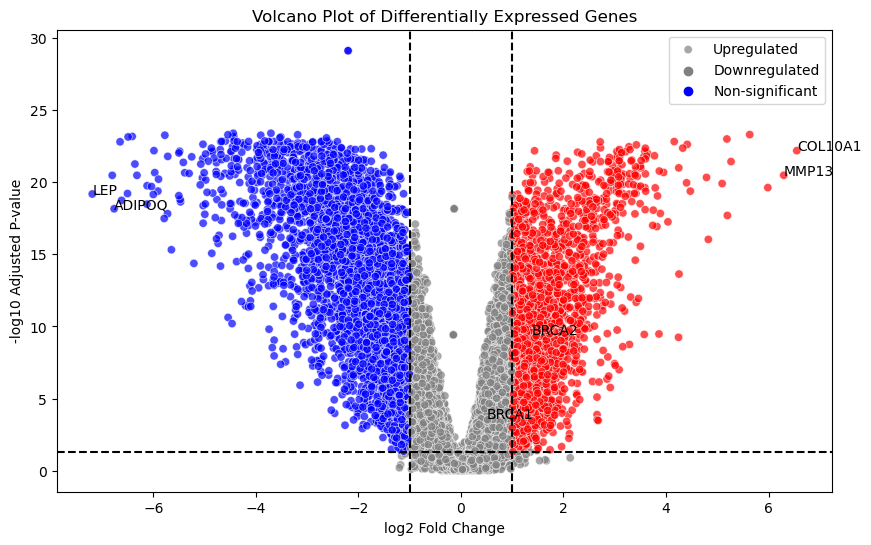

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define thresholds for significance and fold change
sig_threshold = 0.05  # Adjusted p-value cutoff
fc_threshold = 1  # log2 fold change cutoff

# Assign colors
dge_results["color"] = "grey"  # Default to grey
dge_results.loc[(dge_results["adj_p_value"] < sig_threshold) & (dge_results["log2FC"] > fc_threshold), "color"] = "red"
dge_results.loc[(dge_results["adj_p_value"] < sig_threshold) & (dge_results["log2FC"] < -fc_threshold), "color"] = "blue"

# Create plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dge_results,
    x="log2FC",
    y=-np.log10(dge_results["adj_p_value"]),
    hue="color",
    palette={"grey": "grey", "red": "red", "blue": "blue"},
    alpha=0.7
)

# Annotate key genes
top_genes = ["BRCA1", "BRCA2", "COL10A1", "MMP13", "LEP", "ADIPOQ"]  # Add more if needed
for gene in top_genes:
    subset = dge_results[dge_results["Gene"] == gene]
    if not subset.empty:
        plt.text(subset["log2FC"].values[0], -np.log10(subset["adj_p_value"].values[0]), gene, fontsize=10)

plt.axvline(x=fc_threshold, color="black", linestyle="--")  # Upregulation cutoff
plt.axvline(x=-fc_threshold, color="black", linestyle="--")  # Downregulation cutoff
plt.axhline(y=-np.log10(sig_threshold), color="black", linestyle="--")  # Significance cutoff

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Volcano Plot of Differentially Expressed Genes")
plt.legend(["Upregulated", "Downregulated", "Non-significant"], loc="upper right")
plt.show()


# Gene Annotation of Counts


In [52]:
# Define file path
gtf_file = "/Users/nicklucido/Desktop/CapstoneData/gencode.v36.annotation.gtf"

# Load GTF file (skip comments)
gtf_df = pd.read_csv(gtf_file, sep="\t", comment="#", header=None, names=[
    "chromosome", "source", "feature", "start", "end", "score", "strand", "frame", "attributes"
])

# Function to extract gene_id and gene_name from the attributes column
def extract_gene_info(attributes):
    gene_id_match = re.search(r'gene_id "([^"]+)"', attributes)
    gene_name_match = re.search(r'gene_name "([^"]+)"', attributes)
    
    gene_id = gene_id_match.group(1) if gene_id_match else None
    gene_name = gene_name_match.group(1) if gene_name_match else None
    
    return pd.Series([gene_id, gene_name])

# Apply function to extract gene annotations
gtf_df[["gene_id", "gene_name"]] = gtf_df["attributes"].apply(extract_gene_info)

# Keep only gene-level annotations
gene_annotations = gtf_df[gtf_df["feature"] == "gene"][["gene_id", "gene_name"]]

# Merge counts_df with gene_annotations on gene_id
merged_df = gene_annotations.merge(counts_df, left_on="gene_id", right_index=True, how="inner")

# Reorder columns to have gene_name first, then gene_id, then expression data
column_order = ["gene_name", "gene_id"] + [col for col in merged_df.columns if col not in ["gene_name", "gene_id"]]
merged_df = merged_df[column_order]

merged_df.rename(columns={"gene_name": "Gene", "gene_id": "Gene ID"}, inplace=True)
merged_df.set_index("Gene ID", inplace=True)

merged_df.head()


,Gene,TCGA-B6-A0RO-01A,TCGA-B6-A0X0-01A,TCGA-AR-A1AY-01A,TCGA-E2-A15O-01A,TCGA-EW-A6SC-01A,TCGA-E2-A572-01A,TCGA-A2-A0CW-01A,TCGA-D8-A13Y-01A,TCGA-AO-A125-01A,TCGA-AN-A0XW-01A,TCGA-A1-A0SQ-01A,TCGA-GM-A2DL-01A,TCGA-AO-A0JL-01A,TCGA-AO-A0J2-01A,TCGA-OL-A5RY-01A,TCGA-D8-A1X9-01A,TCGA-AO-A03R-01A,TCGA-BH-A18M-01A,TCGA-D8-A1JI-01A,TCGA-EW-A2FW-01A,TCGA-OL-A5DA-01A,TCGA-B6-A0IG-01A,TCGA-EW-A1IX-01A,TCGA-A2-A25B-01A,TCGA-C8-A134-01A,TCGA-AN-A0AM-01A,TCGA-A7-A13E-01A,TCGA-S3-AA11-01A,TCGA-S3-AA14-01A,TCGA-AO-A0JF-01A,TCGA-E2-A106-01A,TCGA-BH-A0GY-01A,TCGA-E9-A1RH-01A,TCGA-OL-A5RX-01A,TCGA-AN-A0XV-01A,TCGA-C8-A12T-01A,TCGA-EW-A2FV-01A,TCGA-AN-A0AS-01A,TCGA-LL-A5YM-01A,TCGA-C8-A26X-01A,TCGA-C8-A275-01A,TCGA-E9-A1R6-01A,TCGA-A2-A0D1-01A,TCGA-E2-A1B5-01A,TCGA-A2-A04N-01A,TCGA-A2-A0EW-01A,TCGA-C8-A1HJ-01A,TCGA-BH-A18S-01A,TCGA-AR-A1AK-01A,TCGA-AR-A250-01A,TCGA-BH-A42V-01A,TCGA-E9-A22B-01A,TCGA-BH-A1FJ-01A,TCGA-BH-A0E1-01A,TCGA-D8-A1XJ-01A,TCGA-A2-A0EQ-01A,TCGA-D8-A73W-01A,TCGA-E2-A107-01A,TCGA-AQ-A54O-01A,TCGA-BH-A0HL-01A,TCGA-E2-A1B6-01A,TCGA-BH-A18Q-01A,TCGA-E9-A1N6-01A,TCGA-D8-A1XQ-01A,TCGA-D8-A1X7-01A,TCGA-OL-A6VQ-01A,TCGA-GM-A4E0-01A,TCGA-AC-A62V-01A,TCGA-AC-A2QJ-01A,TCGA-A2-A0ST-01A,TCGA-BH-A209-01A,TCGA-LD-A7W6-01A,TCGA-E9-A54Y-01A,TCGA-BH-A1F2-01A,TCGA-AQ-A0Y5-01A,TCGA-AR-A1AN-01A,TCGA-EW-A1OX-01A,TCGA-B6-A0IK-01A,TCGA-A7-A13D-01A,TCGA-EW-A6S9-01A,TCGA-BH-A0DI-01A,TCGA-A7-A56D-01A,TCGA-A7-A0D9-11A,TCGA-E9-A1RI-11A,TCGA-A7-A13F-11A,TCGA-AC-A23H-11A,TCGA-BH-A0DG-11A,TCGA-BH-A0H7-11A,TCGA-BH-A1FU-11A,TCGA-BH-A18K-11A,TCGA-BH-A1F2-11A,TCGA-BH-A18R-11A,TCGA-E2-A1LS-11A,TCGA-E9-A1RF-11A,TCGA-BH-A0BC-11A,TCGA-BH-A0B5-11A,TCGA-BH-A0BT-11A,TCGA-BH-A209-11A,TCGA-BH-A0DK-11A,TCGA-BH-A0DD-11A,TCGA-BH-A1FC-11A,TCGA-BH-A204-11A,TCGA-BH-A1EN-11A,TCGA-AC-A2FF-11A,TCGA-E2-A153-11A,TCGA-A7-A0DB-11A,TCGA-BH-A0DZ-11A,TCGA-BH-A1EU-11A,TCGA-BH-A18M-11A,TCGA-E9-A1R7-11A,TCGA-E2-A158-11A,TCGA-BH-A0HA-11A,TCGA-BH-A18L-11A,TCGA-A7-A13E-11A,TCGA-BH-A18N-11A,TCGA-BH-A0BA-11A,TCGA-BH-A18Q-11A,TCGA-GI-A2C8-11A,TCGA-BH-A208-11A,TCGA-E2-A1L7-11A,TCGA-BH-A0BQ-11A,TCGA-BH-A0DL-11A,TCGA-BH-A0H9-11A,TCGA-BH-A18U-11A,TCGA-E9-A1RH-11A,TCGA-A7-A0CE-11A,TCGA-BH-A0H5-11A,TCGA-E9-A1NG-11A,TCGA-BH-A1FN-11A,TCGA-E9-A1N4-11A,TCGA-BH-A18V-11A,TCGA-E9-A1NF-11A,TCGA-E9-A1RC-11A,TCGA-E9-A1N5-11A,TCGA-E9-A1N9-11A,TCGA-BH-A0BM-11A,TCGA-BH-A0B8-11A,TCGA-BH-A1FB-11A,TCGA-BH-A0AU-11A,TCGA-E2-A1IG-11A,TCGA-GI-A2C9-11A,TCGA-BH-A0DV-11A,TCGA-BH-A0BZ-11A,TCGA-E9-A1N6-11A,TCGA-BH-A0DO-11A,TCGA-A7-A0DC-11A,TCGA-E9-A1RB-11A,TCGA-AC-A2FB-11A,TCGA-BH-A0E1-11A,TCGA-BH-A18S-11A,TCGA-BH-A0C3-11A,TCGA-BH-A0AZ-11A,TCGA-A7-A0CH-11A,TCGA-BH-A0AY-11A,TCGA-BH-A18P-11A,TCGA-BH-A18J-11A,TCGA-E9-A1RD-11A,TCGA-BH-A0DT-11A,TCGA-BH-A1EV-11A,TCGA-BH-A0HK-11A,TCGA-BH-A203-11A,TCGA-BH-A0C0-11A,TCGA-E2-A15I-11A,TCGA-BH-A0DP-11A
Gene ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972.5,DDX11L1,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.584963,0.0,0.000000,0.000000,0.000000,0.000000,0.584963,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,1.000000,0.000000,0.000000,0.00000,0.0

In [60]:
merged_df.shape

(60660, 165)

In [62]:
# Step 1: Exclude gene_id and gene_name columns from merged_df
counts_tcga_ids = merged_df.columns.difference(["Gene Id", "Gene"])

# Step 2: Get TCGA IDs from metadata_df index
metadata_tcga_ids = metadata_df.index

# Step 3: Check if they match
if set(counts_tcga_ids) == set(metadata_tcga_ids):
    print("The TCGA IDs align in both dataframes.")
else:
    print("The TCGA IDs do not align in both dataframes.")
    
    # Find mismatched IDs
    missing_in_counts = set(metadata_tcga_ids) - set(counts_tcga_ids)
    missing_in_metadata = set(counts_tcga_ids) - set(metadata_tcga_ids)

    print(f"IDs in metadata_df but not in counts_df: {missing_in_counts}")
    print(f"IDs in counts_df but not in metadata_df: {missing_in_metadata}")


The TCGA IDs align in both dataframes.


# Ensure that filtered_counts and metadata samples align 

In [64]:
# Ensure the first column (gene identifiers) is excluded dynamically
counts_tcga_ids = filtered_counts.columns[1:]  # Exclude first column

# Get TCGA IDs from metadata index
metadata_tcga_ids = metadata.index

# Check alignment
if set(counts_tcga_ids) == set(metadata_tcga_ids):
    print("The TCGA IDs align in both dataframes.")
else:
    print("The TCGA IDs do not align in both dataframes.")

    # Identify mismatched IDs
    missing_in_counts = set(metadata_tcga_ids) - set(counts_tcga_ids)
    missing_in_metadata = set(counts_tcga_ids) - set(metadata_tcga_ids)

    print(f"IDs in metadata but not in counts: {missing_in_counts}")
    print(f"IDs in counts but not in metadata: {missing_in_metadata}")

    # Align the dataframes by selecting common TCGA IDs
    common_tcga_ids = sorted(set(counts_tcga_ids) & set(metadata_tcga_ids))
    
    # Reorder and filter counts dataframe
    filtered_counts = filtered_counts.loc[:, [filtered_counts.columns[0]] + common_tcga_ids]

    # Reorder metadata dataframe
    metadata = metadata.loc[common_tcga_ids]

    print("Dataframes have been aligned.")



The TCGA IDs align in both dataframes.


# Save Data (Count, Metadata) to CSV Files 

In [ ]:
merged_df.to_csv("processed_counts.csv", index=True)  # Ensures genes remain as index
metadata_df.to_csv("processed_metadata.csv", index=True)  # Keeps TCGA IDs as index

## Data Exploration

In [66]:
# Filter for columns that end with '11A'
columns_with_11A = [col for col in rna_seq_df.columns if col.endswith('11A')]

# Check the total number of columns that end with '11A'
total_columns_with_11A = len(columns_with_11A)

# Print the total number
print(f"Total number of columns ending with '11A': {total_columns_with_11A}")




Total number of columns ending with '11A': 0


In [ ]:
survival_df = pd.read_csv('/Users/nicklucido/Desktop/CapstoneData/TCGA-BRCA.survival.tsv', sep='\t')  

pd.set_option('display.max_rows', None) 
survival_df.head(1232)
